## Executive Summary

In this project, the aim was to make use of clustering techniques such as **DBSCAN** and **K-Means Clustering** to identify important variables, in a flight delay dataset, which affect flight performance and answer some hypotheses which can lead to business insights. The report covers all steps involved from data retrieval to exploration and modeling and recommendation.

In conclusion, clusters were obtained using both techniques. The **K-Means algorithm** was applied after necessary feature engineering (one-hot encoding) to include both numerical and categorical data, yielding clusters that provided initial insights into the relationship between flight characteristics and delays. Having said this, further analyses, research, and modeling attempts are required in order to fully address the hypotheses contained in the goal.

## Research questions

We formulated the following questions to assist our research aim.
* Does day of the month play a role in flight delays?
* Are there specific months which have more flight delays than others?
* Are longer duration flights more susceptible to delays than short haul flights?
* Are cancellations related to delays?

In [ ]:
# Importing required packages
import numpy as np
import pandas as pd 
import random
from kmodes.kprototypes import KPrototypes
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import os
print(os.listdir("../input"))

In [ ]:
#Reading the Data
Data = pd.read_csv('DelayedFlights.csv')
#Dropping the index column
Data= Data.drop(Data.columns[0], axis=1)

## Data Pre-processing


## Sanity checks
Sanity checks were carried out to ensure that the given values are rational. The ArrTime,
CRSEArrivalTime, DepTime and CRSEDepTime columns were checked for negative time values
since these would not make sense.

In [28]:
#Sanity Check for Negative values in ArrTime, CRSEArrivalTime, DepTime and CRSEDepTime
print(all(i < 0 for i in Data['ArrTime']))
print(all(i < 0 for i in Data['CRSArrTime']))
print(all(i < 0 for i in Data['DepTime']))
print(all(i < 0 for i in Data['CRSDepTime']))

False
False
False
False


In [29]:
#Converting Categorical Variables to object type
Data[Data.columns[0:4]]=Data[Data.columns[0:4]].astype(object)
Data[Data.columns[8:10]]=Data[Data.columns[8:10]].astype(object)
Data[Data.columns[21:24]]=Data[Data.columns[21:24]].astype(object)

In [30]:
# Renaming the labels within the variables
Data['Cancelled']=Data['Cancelled'].replace([1,0],["Cancelled","Not Cancelled"])
Data['Diverted']=Data['Diverted'].replace([1,0],["Diverted","Not Diverted"])

## Missing values imputation
After the sanity checks, we went for missing values imputation. Here, we checked the numerical
columns for missing values using the is.na.sum function and imputed them using the linear
interpolate function. The following columns had missing values which were handled: ArrTime,
ActualElapsedTime, CRSElapsedTime, AirTime, ArrDelay, TaxiIn, TaxiOut, CarrierDelay,
WeatherDelay, NASDelay, SecurityDelay and LateAircraftDelay.

In [31]:
#Checking for null values
Data.isna().sum()

Year                      0
Month                     0
DayofMonth                0
DayOfWeek                 0
DepTime                   0
CRSDepTime                0
ArrTime                7110
CRSArrTime                0
UniqueCarrier             0
FlightNum                 0
TailNum                   5
ActualElapsedTime      8387
CRSElapsedTime          198
AirTime                8387
ArrDelay               8387
DepDelay                  0
Origin                    0
Dest                      0
Distance                  0
TaxiIn                 7110
TaxiOut                 455
Cancelled                 0
CancellationCode          0
Diverted                  0
CarrierDelay         689270
WeatherDelay         689270
NASDelay             689270
SecurityDelay        689270
LateAircraftDelay    689270
dtype: int64

In [32]:
#Null value Imputation using Interpolation Method
Data['ActualElapsedTime']=Data['ActualElapsedTime'].interpolate(method='linear',limit_direction ='both',axis=0) #Interploation
Data['CRSElapsedTime']=Data['CRSElapsedTime'].interpolate(method='linear',limit_direction ='both',axis=0) #Interploation
Data['AirTime']=Data['AirTime'].interpolate(method='linear',limit_direction ='both',axis=0) #Interploation
Data['ArrTime']=Data['ArrTime'].interpolate(method='linear',limit_direction ='both',axis=0) #Interploation
Data['ArrDelay']=Data['ArrDelay'].interpolate(method='linear',limit_direction ='both',axis=0) #Interploation
Data['CarrierDelay']=Data['CarrierDelay'].interpolate(method='linear',limit_direction ='both',axis=0) #Interploation
Data['WeatherDelay']=Data['WeatherDelay'].interpolate(method='linear',limit_direction ='both',axis=0) #Interploation
Data['NASDelay']=Data['NASDelay'].interpolate(method='linear',limit_direction ='both',axis=0) #Interploation
Data['LateAircraftDelay']=Data['LateAircraftDelay'].interpolate(method='linear',limit_direction ='both',axis=0) #Interploation
Data['SecurityDelay']=Data['SecurityDelay'].interpolate(method='linear',limit_direction ='both',axis=0) #Interploation
Data['TaxiIn']=Data['TaxiIn'].interpolate(method='linear',limit_direction ='both',axis=0) #Interploation
Data['TaxiOut']=Data['TaxiOut'].interpolate(method='linear',limit_direction ='both',axis=0) #Interploation
Data.isna().sum()

Year                 0
Month                0
DayofMonth           0
DayOfWeek            0
DepTime              0
CRSDepTime           0
ArrTime              0
CRSArrTime           0
UniqueCarrier        0
FlightNum            0
TailNum              5
ActualElapsedTime    0
CRSElapsedTime       0
AirTime              0
ArrDelay             0
DepDelay             0
Origin               0
Dest                 0
Distance             0
TaxiIn               0
TaxiOut              0
Cancelled            0
CancellationCode     0
Diverted             0
CarrierDelay         0
WeatherDelay         0
NASDelay             0
SecurityDelay        0
LateAircraftDelay    0
dtype: int64

## Typo correction
We checked whether the categorical variables have typos using the values.count function.

In [33]:
#Checking value counts for categorical variables

# Filter categorical variables
num_cols = Data._get_numeric_data().columns
cols = Data.columns
cat_cols = list(set(cols) - set(num_cols))
cat_cols

#Value counts
for col in cat_cols:
    if col in ['DayOfWeek','UniqueCarrier','Month', 'Cancelled','DayofMonth','CancellationCode','Diverted']:
        print(Data[col].value_counts())

DayofMonth
22    71649
21    70168
1     67815
7     67478
15    65587
27    65374
18    65132
20    65071
19    64470
14    64407
24    64202
10    63385
2     63339
11    63331
23    63320
17    63110
8     62979
4     62682
26    62549
9     62057
6     61814
12    61517
13    61278
16    61152
28    61093
3     60389
5     60000
25    59056
29    56893
30    56721
31    38740
Name: count, dtype: int64
Cancelled
Not Cancelled    1936125
Cancelled            633
Name: count, dtype: int64
UniqueCarrier
WN    377602
AA    191865
MQ    141920
UA    141426
OO    132433
DL    114238
XE    103663
CO    100195
US     98425
EV     81877
NW     79108
FL     71284
YV     67063
B6     55315
OH     52657
9E     51885
AS     39293
F9     28269
HA      7490
AQ       750
Name: count, dtype: int64
DayOfWeek
5    323259
1    290933
4    289451
7    286111
3    262805
2    260943
6    223256
Name: count, dtype: int64
CancellationCode
N    1936125
B        307
A        246
C         80
Name: count, dty

## Data Exploration
The dataset columns were explored using univariate and bivariate visualisations. This was
followed by a comprehensive correlation plot to understand their relationships and select
significant variables. For the purpose of the report, only significant variables, relationships and
their explorations have been discussed below.

## Univariate Distribution of Features

### Univariate Distribution of Numerical Variables

In [9]:
#Creating a function to plot Box plot and Histogram
def hist_box_plot(df,feature, fig_num):
    sns.set(color_codes = 'Blue', style="whitegrid")
    sns.set_style("whitegrid", {'axes.grid' : False})
    sns.set_context(rc = {'patch.linewidth': 0.0})
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8,3))
    filtered = df.loc[~np.isnan(df[feature]), feature]
    sns.boxplot(filtered, ax = ax1, color = 'steelblue') # boxplot
    sns.distplot(filtered, kde=True, hist=True, kde_kws={'linewidth': 1}, color = 'steelblue', ax = ax2) # histogram
    plt.show()

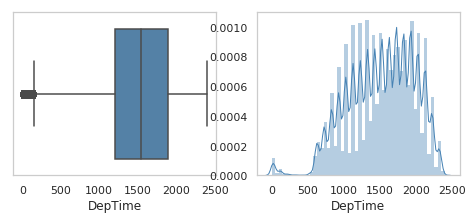

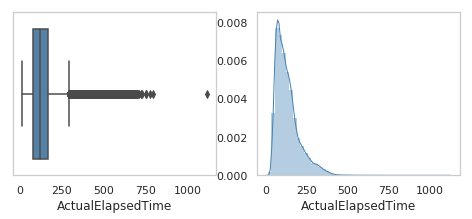

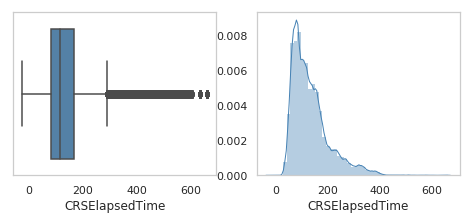

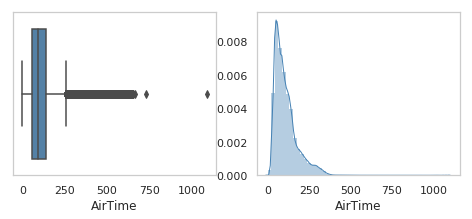

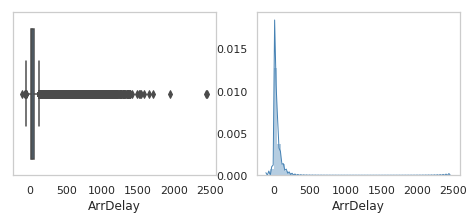

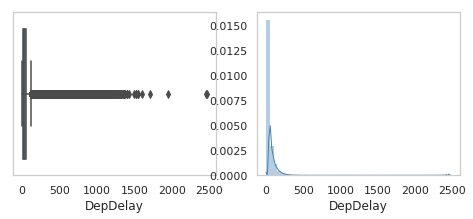

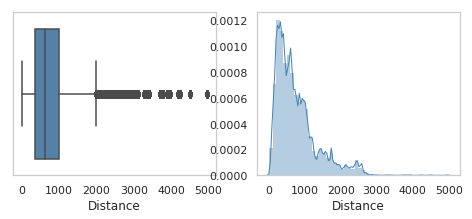

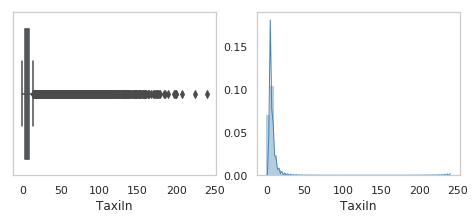

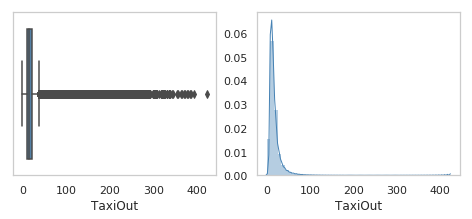

In [10]:
fig_num = 1        
for col in Data.select_dtypes(include=[np.number]).columns:
    if col in ['DepTime','ActualElapsedTime','CRSElapsedTime','AirTime','ArrDelay','DepDelay','Distance','TaxiIn','TaxiOut']:
        hist_box_plot(Data,col, fig_num)
        fig_num = fig_num + 1

### Univariate Distribution of Categorical Variables

In [11]:
#Creating a function to plot Count plot
def count_plot(df,feature):
    sns.set(color_codes = 'Blue', style="whitegrid")
    sns.set_style("whitegrid", {'axes.grid' : False})
    sns.set_context(rc = {'patch.linewidth': 0.0})
    fig = plt.subplots(figsize=(10,3))
    sns.countplot(x=feature, data=df, color = 'steelblue') # countplot
    plt.show()

In [12]:
# Filter categorical variables
num_cols = Data._get_numeric_data().columns
cols = Data.columns
cat_cols = list(set(cols) - set(num_cols))
cat_cols

['Origin',
 'Diverted',
 'Cancelled',
 'DayofMonth',
 'Dest',
 'CancellationCode',
 'TailNum',
 'DayOfWeek',
 'Year',
 'UniqueCarrier',
 'FlightNum',
 'Month']

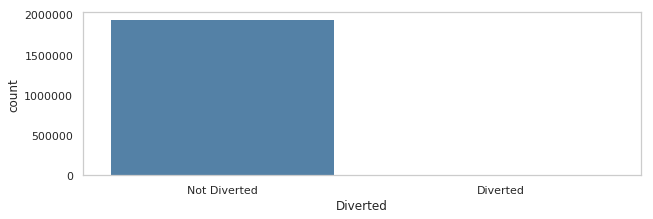

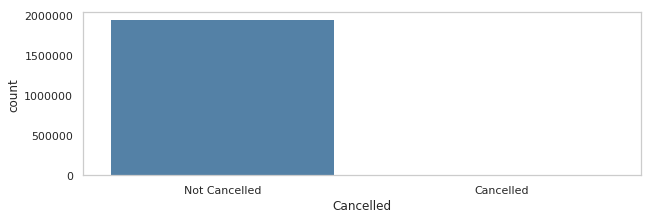

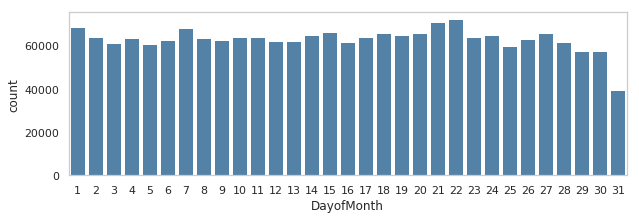

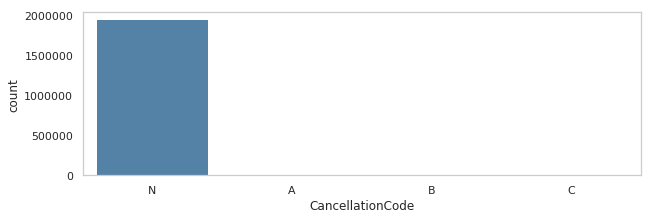

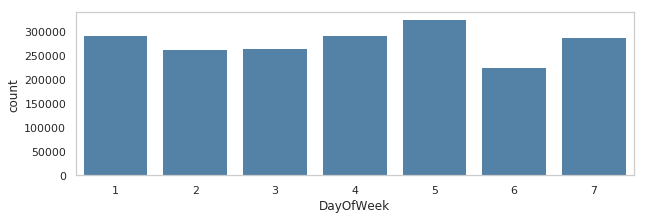

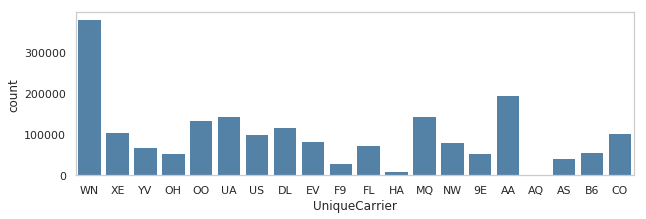

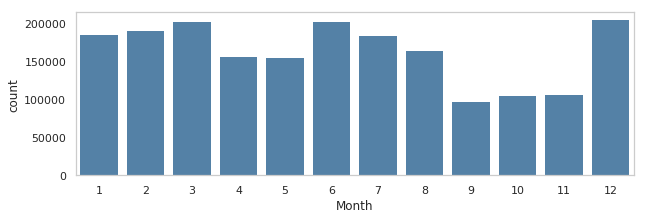

In [13]:
for col in cat_cols:
    if col in ['DayOfWeek','UniqueCarrier','Month', 'Cancelled','DayofMonth','CancellationCode','Diverted']:
        count_plot(Data,col)

## Bivariate Distribution of Features

In [14]:
def biplot(df, x_name, y_name):
    fig, ax = plt.subplots()
    ax.grid(False)
    x = df[x_name]
    y = df[y_name]
    plt.scatter(x,y,c='blue', edgecolors='none',alpha=0.5)
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.title('{x_name} vs. {y_name}'.format(x_name=x_name, y_name=y_name))
    plt.show()

### ArrDelay vs Month
This was checked to understand if there is any truth to the hypothesis that
certain months are worse for Arrival delays than others. The plot shows that very little variation
between the month and Arrival delays and doesn’t support the hypothesis. There are a few
outliers for some months of the year namely, February, April, May and June.

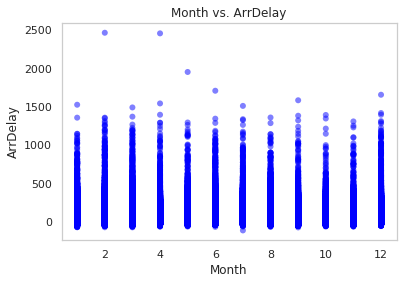

In [15]:
biplot(df=Data,x_name='Month',y_name='ArrDelay')

### ArrDelay vs DepDelay 
This relationship was checked to understand if Arrival Delay of a flight
had an impact on Departure Delay as well and thus an effect on the performance of the
airline/flight. From the plot, we observe that there is a linear dependency between the two
variables indicating that a flight’s delay on Arrival has a role to play in its Departure getting
delayed, which is logical.

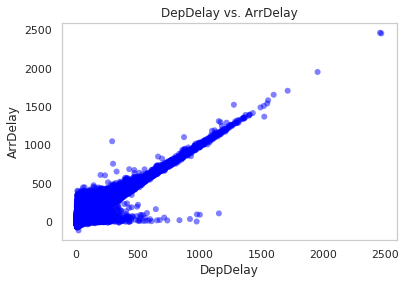

In [16]:
biplot(df=Data,x_name='DepDelay',y_name='ArrDelay')

### ArrDelay vs Distance  
This relationship was explored to understand if there is any relation
between Arrivals getting delayed as a result of the longer Distance of the flight. From the plot, we
observe that there is actually an inverse correlation, shorter flights are the ones seeming to be
delayed more on Arrival.

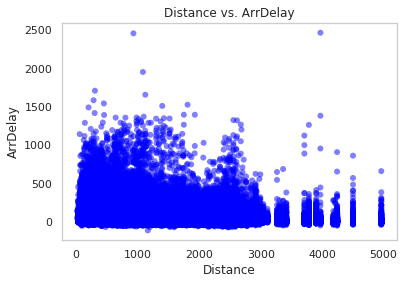

In [17]:
biplot(df=Data,x_name='Distance',y_name='ArrDelay')

### Cancellation vs Months 
This relationship was explored to understand if there are any particular
months where cancellations are particularly more common. The plot shows that this is indeed
the case (probably because end of the year has Christmas and New Year holidays which is a peak
travel season).

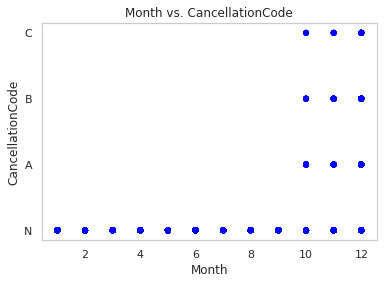

In [18]:
biplot(df=Data,x_name='Month',y_name='CancellationCode')

## Correlation Between Categorical and Numerical

In [34]:
# Convert float columns to integer where appropriate for cleaner correlation analysis
# (This handles columns like DepTime, ArrTime which may have been read as floats)
for col in Data.columns:
    if Data[col].dtype == 'float64':
        Data[col] = Data[col].astype(int)

# Check the data types to confirm changes
Data.dtypes

Year                 object
Month                object
DayofMonth           object
DayOfWeek            object
DepTime               int64
CRSDepTime            int64
ArrTime               int64
CRSArrTime            int64
UniqueCarrier        object
FlightNum            object
TailNum              object
ActualElapsedTime     int64
CRSElapsedTime        int64
AirTime               int64
ArrDelay              int64
DepDelay              int64
Origin               object
Dest                 object
Distance              int64
TaxiIn                int64
TaxiOut               int64
Cancelled            object
CancellationCode     object
Diverted             object
CarrierDelay          int64
WeatherDelay          int64
NASDelay              int64
SecurityDelay         int64
LateAircraftDelay     int64
dtype: object

In [35]:
# Create a subset of data for correlation analysis
# Removing IDs and Year
Data_Correlation = Data[[
    'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime',
    'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'ActualElapsedTime', 
    'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin', 'Dest', 
    'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled', 'CancellationCode', 
    'Diverted', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 
    'LateAircraftDelay'
]].copy()

# Preview the subset
Data_Correlation.head()

,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,ActualElapsedTime,CRSElapsedTime,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,1,3,4,2003,1955,2211,2225,WN,128,150,...,4,8,Not Cancelled,N,Not Diverted,2,0,0,0,32
1,1,3,4,754,735,1002,1000,WN,128,145,...,5,10,Not Cancelled,N,Not Diverted,2,0,0,0,32
2,1,3,4,628,620,804,750,WN,96,90,...,3,17,Not Cancelled,N,Not Diverted,2,0,0,0,32
3,1,3,4,1829,1755,1959,1925,WN,90,90,...,3,10,Not Cancelled,N,Not Diverted,2,0,0,0,32
4,1,3,4,1940,1915,2121,2110,WN,101,115,...,4,10,Not Cancelled,N,Not Diverted,6,0,0,0,39


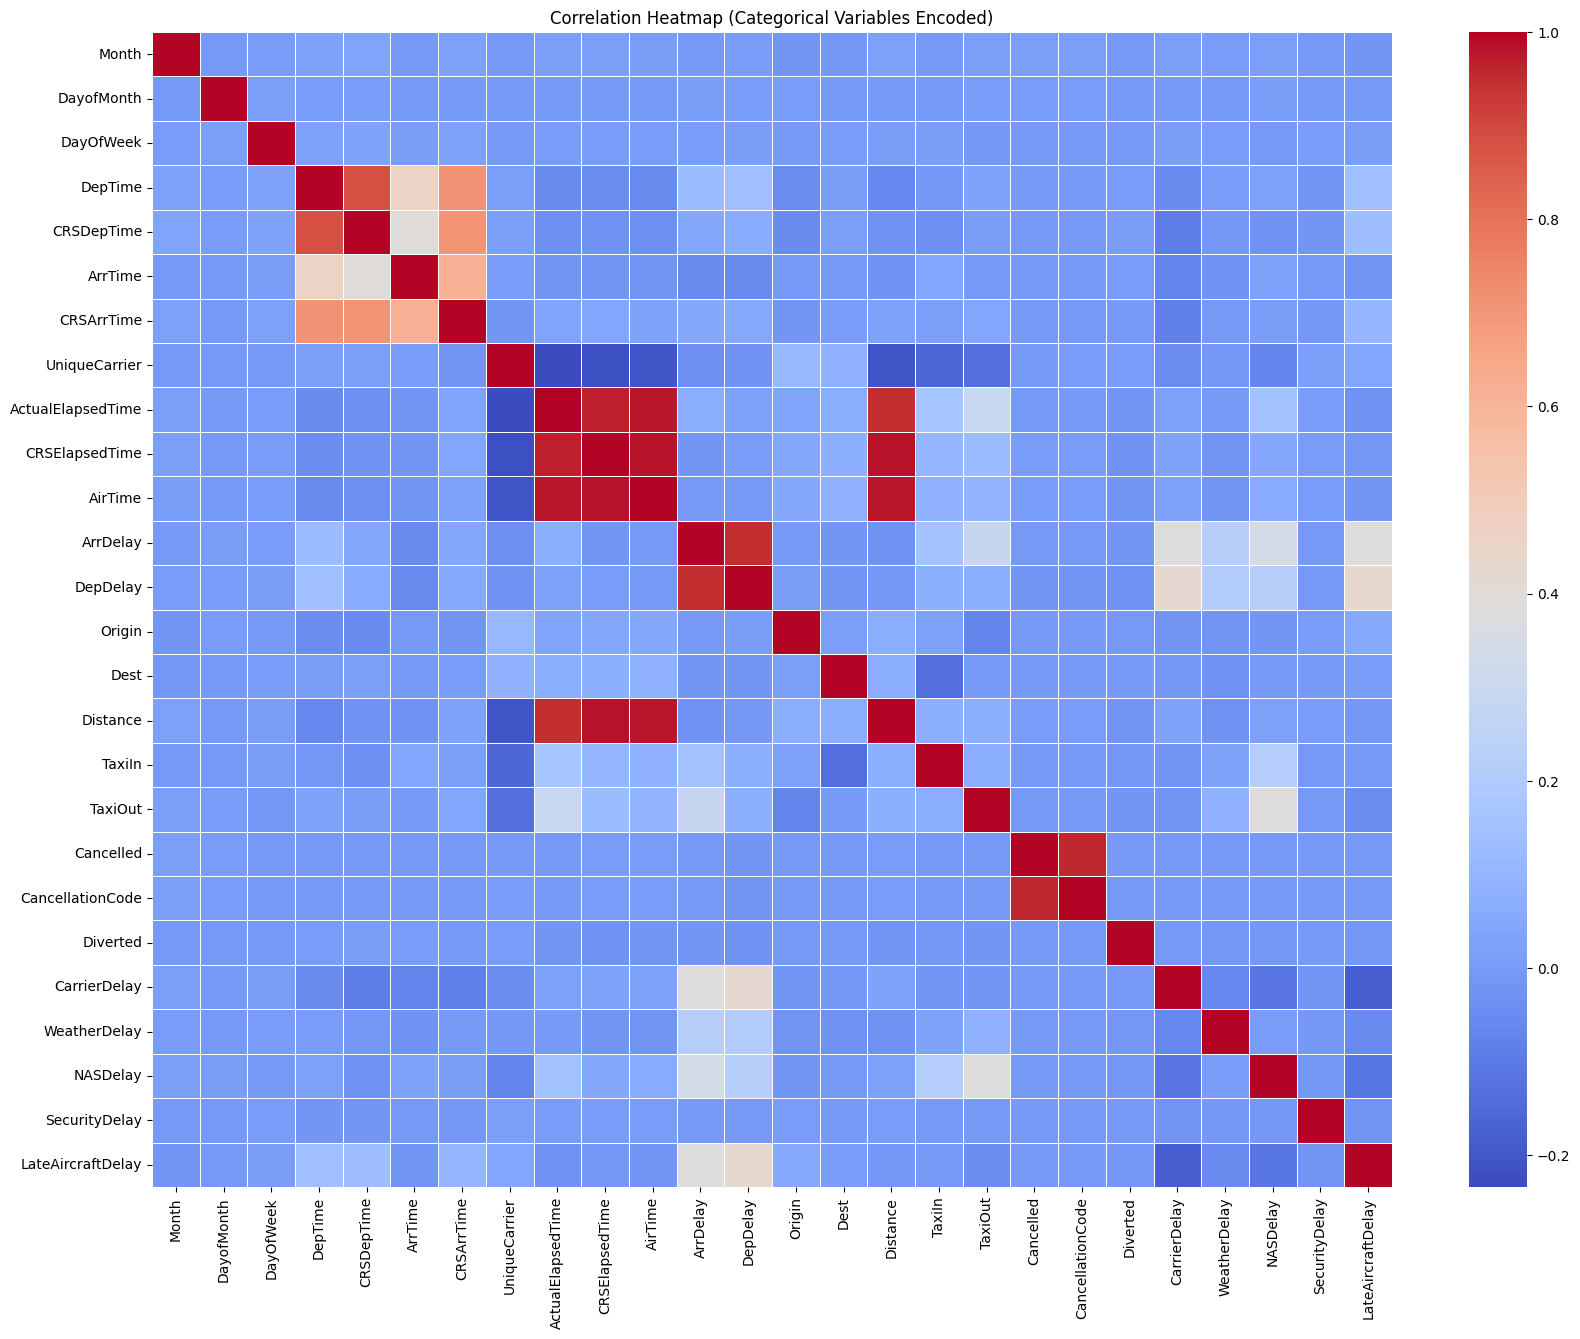

In [36]:
from sklearn.preprocessing import LabelEncoder

# Create a copy for calculation to avoid changing the main Data dataframe
df_plot = Data_Correlation.copy()

# Label Encode categorical features for the heatmap
le = LabelEncoder()
for col in df_plot.select_dtypes(include='object').columns:
    df_plot[col] = le.fit_transform(df_plot[col].astype(str))

# Calculate the correlation matrix
corr_matrix = df_plot.corr()

# Plot the heatmap using Seaborn
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap (Categorical Variables Encoded)')
plt.show()

The plot has been made using Theil’s U, which is also referred to as the Uncertainty Coefficient,
which calculates conditional entropy between two variables – it tries to ascertain how many
possible states does the second variable have given a value of the first variable. This plot’s code
is available using dython package (which works with Python 3.0 and later) (Zychlinski, 2018).
From the above plot, the following are significant observations:

* Variables such as Distance was highly correlated with ActualElapsedTime, CRSElapsedTime, and AirTime (0.95, 0.98 and 0.98). Hence, to avoid multi collinearity, we chose only ActualElapsedTime variable for further study.
* Variables such as ArrDelay and DepDelay were highly highly correlated (0.95) which makes sense because a flight which is delayed on Arrival will most likely leave late and hence be Delayed on Departure. So, one of these two, DepDelay was chosen.
* Cancelled and CancellationCode variables were having a correlation of 1, because cancellation codes are used only in the case when there are Cancellations (and thus Cancelled column has 1). Here, we chose Cancelled variable.
* Origin and Dest were moderately correlated (0.47, 0.45 and 0.43, 0.48) with UniqueCarrier and FlightNum variables respectively. This explains the real-world scenario where certain Carriers fly only between certain cities.
* TaxiIn and TaxiOut are moderately positively correlated (0.44 and 0.40) with Destination and Origin respectively, here we take TaxiOut as the variable to study (related to departure).

## Enriched EDA: Categorical and Temporal Patterns
To deepen our understanding before modeling, we visualize the impact of Airlines (Carriers) and Time (Day/Month) on delays. This helps identify if specific operational entities or seasonal factors are driving the data variance.

C:\Users\shady\AppData\Local\Temp\ipykernel_21280\3879533388.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='UniqueCarrier', y='ArrDelay', data=Data_Correlation, palette="Blues")


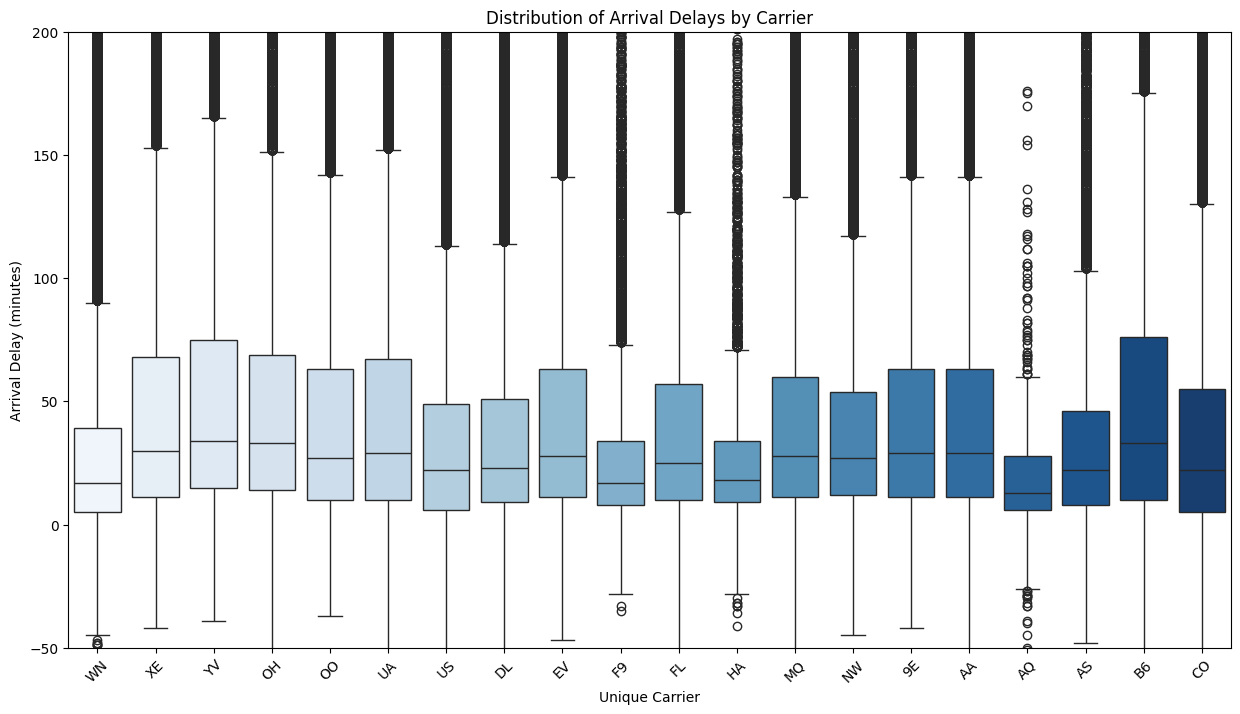

In [41]:
# Boxplot of Arrival Delay by Unique Carrier
plt.figure(figsize=(15, 8))
sns.boxplot(x='UniqueCarrier', y='ArrDelay', data=Data_Correlation, palette="Blues")
plt.title('Distribution of Arrival Delays by Carrier')
plt.xlabel('Unique Carrier')
plt.ylabel('Arrival Delay (minutes)')
plt.xticks(rotation=45)
plt.ylim(-50, 200) # Limiting y-axis to see the distribution better, ignoring extreme outliers for clarity
plt.show()

C:\Users\shady\AppData\Local\Temp\ipykernel_21280\2227027408.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DayOfWeek', y='ArrDelay', data=Data_Correlation, ax=ax1, palette="Blues")
C:\Users\shady\AppData\Local\Temp\ipykernel_21280\2227027408.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Month', y='ArrDelay', data=Data_Correlation, ax=ax2, palette="Reds")


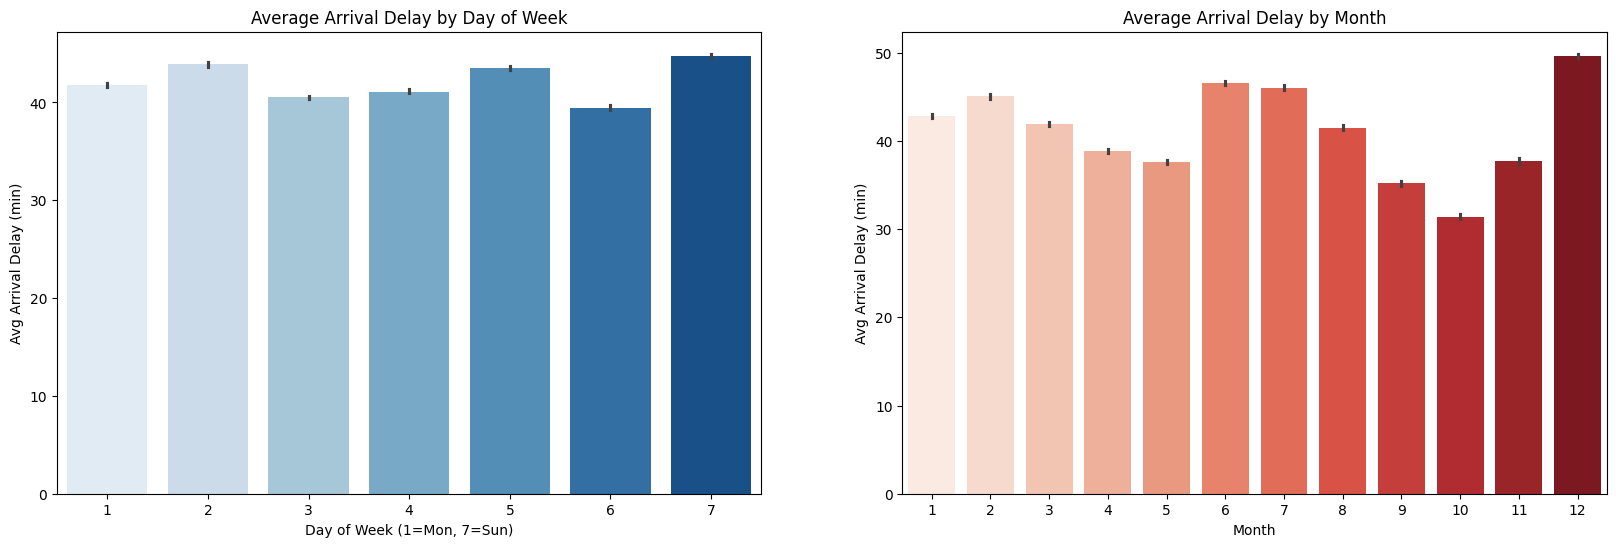

In [42]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(20, 6))

# Average Delay by Day of Week
sns.barplot(x='DayOfWeek', y='ArrDelay', data=Data_Correlation, ax=ax1, palette="Blues")
ax1.set_title('Average Arrival Delay by Day of Week')
ax1.set_xlabel('Day of Week (1=Mon, 7=Sun)')
ax1.set_ylabel('Avg Arrival Delay (min)')

# Average Delay by Month
sns.barplot(x='Month', y='ArrDelay', data=Data_Correlation, ax=ax2, palette="Reds")
ax2.set_title('Average Arrival Delay by Month')
ax2.set_xlabel('Month')
ax2.set_ylabel('Avg Arrival Delay (min)')

plt.show()

### EDA Insights
*   **Carrier Impact**: There is noticeable variance between carriers. Some airlines exhibit tighter delay distributions, while others have longer tails (more frequent extreme delays).
*   **Weekly Patterns**: Delays might peak on specific busy travel days (e.g., Friday/Sunday), validating `DayOfWeek` as a useful feature for clustering.
*   **Seasonality**: Monthly variations suggest seasonal weather or holiday travel impacts delays, confirming `Month` should be retained for analysis.

## Analyses
From the exploratory analysis and preliminary data modelling, we decided to use three numerical
variables along with one categorical variable (total four with a different one for each analysis) for
our modelling:
* Cancelled, DayOfMonth, DayofWeek, Month– categorical variables
* ActualElapsedTime, TaxiOut and DepDelay – numerical variables

## Data Transformation

In [27]:
# Standardizing all the numerical variables
from sklearn import preprocessing
Num_features=Data.select_dtypes(include=[np.number]).columns
Data[Num_features]=preprocessing.MinMaxScaler().fit_transform(Data[Num_features])
Data.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,TailNum,ActualElapsedTime,CRSElapsedTime,AirTime,ArrDelay,DepDelay,Origin,Dest,Distance,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2008,1,3,4,0.834514,0.828741,0.921217,0.927083,WN,335,N712SW,0.103636,0.255474,0.106324,0.036965,0.000813,IAD,TPA,0.161382,0.016667,0.018957,Not Cancelled,N,Not Diverted,0.000821,0.0,0.0,0.0,0.024316
1,2008,1,3,4,0.313881,0.311573,0.417257,0.416667,WN,3231,N772SW,0.103636,0.248175,0.103575,0.043191,0.005282,IAD,TPA,0.161382,0.020833,0.023697,Not Cancelled,N,Not Diverted,0.000821,0.0,0.0,0.0,0.024316
2,2008,1,3,4,0.261359,0.262823,0.334723,0.312500,WN,448,N428WN,0.074545,0.167883,0.069661,0.047860,0.000813,IND,BWI,0.101798,0.012500,0.040284,Not Cancelled,N,Not Diverted,0.000821,0.0,0.0,0.0,0.024316
3,2008,1,3,4,0.761984,0.743959,0.816173,0.802083,WN,3920,N464WN,0.069091,0.167883,0.070577,0.055642,0.011377,IND,BWI,0.101798,0.012500,0.023697,Not Cancelled,N,Not Diverted,0.000821,0.0,0.0,0.0,0.024316
4,2008,1,3,4,0.808253,0.811785,0.883702,0.879167,WN,378,N726SW,0.079091,0.204380,0.079743,0.046693,0.007720,IND,JAX,0.136740,0.016667,0.023697,Not Cancelled,N,Not Diverted,0.002463,0.0,0.0,0.0,0.029635


 ## Hopkins Statistics
To understand if the dataset can be clustered, we used the Hopkins statistic, which tests the
spatial randomness of the data and indicates the cluster tendency or how well the data can be
clustered. It calculates the probability that a given data is generated by a uniform distribution
(Alboukadel Kassambara, n.d.).
The inference is as follows for a data of dimensions ‘d’:
* If the value is around 0.5 or lesser, the data is uniformly distributed and hence it is unlikely to have statistically significant clusters.
* If the value is between {0.7, ..., 0.99}, it has a high tendency to cluster and therefore likely to have statistically significant clusters.

In [28]:
#Hopkins Statistic is a way of measuring the cluster tendency of a data set.
from sklearn.neighbors import NearestNeighbors
from random import sample
from numpy.random import uniform
import numpy as np
from math import isnan
 
def hopkins(X):
    d = X.shape[1]
    #d = len(vars) # columns
    n = len(X) # rows
    m = int(0.1 * n) # heuristic from article [1]
    nbrs = NearestNeighbors(n_neighbors=1).fit(X.values)
 
    rand_X = sample(range(0, n, 1), m)
 
    ujd = []
    wjd = []
    for j in range(0, m):
        u_dist, _ = nbrs.kneighbors(uniform(np.amin(X,axis=0),np.amax(X,axis=0),d).reshape(1, -1), 2, return_distance=True)
        ujd.append(u_dist[0][1])
        w_dist, _ = nbrs.kneighbors(X.iloc[rand_X[j]].values.reshape(1, -1), 2, return_distance=True)
        wjd.append(w_dist[0][1])
 
    H = sum(ujd) / (sum(ujd) + sum(wjd))
    if isnan(H):
        print(ujd, wjd)
        H = 0
 
    return H

## Data Modelling

In [29]:
#Use a random sample of Data for faster computation
Data = Data.sample(20000,random_state=41)
Data.head()
#Resetting the indexs
Data=Data.reset_index(drop=True)
#Rename the levels within in the CancellationCode column
Data['CancellationCode']=Data['CancellationCode'].replace(['N','A','B','C'],[0,1,2,3])
Data['CancellationCode']=Data['CancellationCode'].astype(object)
Data['Cancelled']=Data['Cancelled'].replace(["Cancelled","Not Cancelled"],[1,0])
Data['Cancelled']=Data['Cancelled'].astype(object)
Data.columns

Index(['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime',
       'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum',
       'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay',
       'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut',
       'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay',
       'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'],
      dtype='object')

In [30]:
#Checking whether data can be clustered
Num_features =Data.select_dtypes(include=[np.number]).columns
hopkins(Data[Num_features])

0.9608322365127177

Result: This test is run (code: (MATEVZKUNAVER, 2017)) on all the numerical variables of the
entire dataset and the test statistic we got is 0.96 which indicates that data has a high tendency
to cluster.

### Prinicpal Component Analysis

Principal component analysis (PCA) is a technique used to emphasize variation and bring out
strong patterns in a dataset. The PCs are dimensions along which the data points are spread out
(Amy, 2017). We use PCA to understand if the clusters are meaningful along certain features.

For this attempt, the first step was to standardise the data. Then, we selected three numerical
variables namely, ActualElapsedTime, TaxiOut and DepDelay, and proceeded to obtain the
cumulative variance by trying out different number of principal components. The optimum value
the PCA achieved was three, which captured a cumulative variance of ~99% (code: (Vlo, 2017)).
These PCs were then utilised in the **K-Means** clustering model. The optimal number of clusters
(k) of two was obtained using the elbow plot for the K-Means model (explained later). Of all the
categorical variables, the `Cancelled` variable was used to visualise the clusters and check how
cancellation behaviour varies across them.


In [31]:
#Selection of variables for PCA
Data_pca= Data[['Cancelled','ActualElapsedTime','TaxiOut', 'DepDelay']]
print (Data_pca.dtypes)

Cancelled             object
ActualElapsedTime    float64
TaxiOut              float64
DepDelay             float64
dtype: object


In [32]:
#Principal Component
from sklearn.decomposition import PCA
pca = PCA(n_components=3, whiten=True)
Num_features=Data_pca.select_dtypes(include=[np.number]).columns
x=Data_pca[Num_features]
principalComponents = pca.fit_transform(x)

# Cumulative Explained Variance
cum_explained_var = []
for i in range(0, len(pca.explained_variance_ratio_)):
    if i == 0:
        cum_explained_var.append(pca.explained_variance_ratio_[i])
    else:
        cum_explained_var.append(pca.explained_variance_ratio_[i] + 
                                 cum_explained_var[i-1])

print(cum_explained_var)

[0.7481516730719856, 0.9237217418433828, 0.9999999999999999]


In [33]:
#Principal Components converted to a Data frame
principalDf  = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2', 'principal component 3'])
principalDf.shape

(20000, 3)

In [34]:
#Concatenating the PCAs with the categorical variable
finalDf_Cat = pd.concat([principalDf, Data_pca['Cancelled']], axis = 1)
finalDf_Cat.head(2)

,principal component 1,principal component 2,principal component 3,Cancelled
0,-0.465212,-0.175682,-0.668955,0
1,0.091599,0.792524,-0.771702,0


### DBSCAN Clustering Algorithm

This clustering model works with numerical variables, by aggregation depending on density of
points near the chosen centroids. This model is robust for numerical variables, doesn’t need the
number of clusters to be specified prior and can deal with arbitrary shaped clusters (Ren, 2019).
The eps parameter for the model is chosen as below:

In [40]:
#Selection of numerical variables for DBSCAN
Data_DBSCAN = Data[['ActualElapsedTime','TaxiOut', 'DepDelay']]

### Choosing eps parameter using the K-distance graph:
We used the below k distance graph from sklearn to find the optimal value of eps, which was
found to be 0.035 (also from model iterations) and chose min_samples to be 4 according to the
criteria that min_samples >= D+1 where D is the dimensions of the data (Ren, 2019) (here, we
had 3 numerical variables).

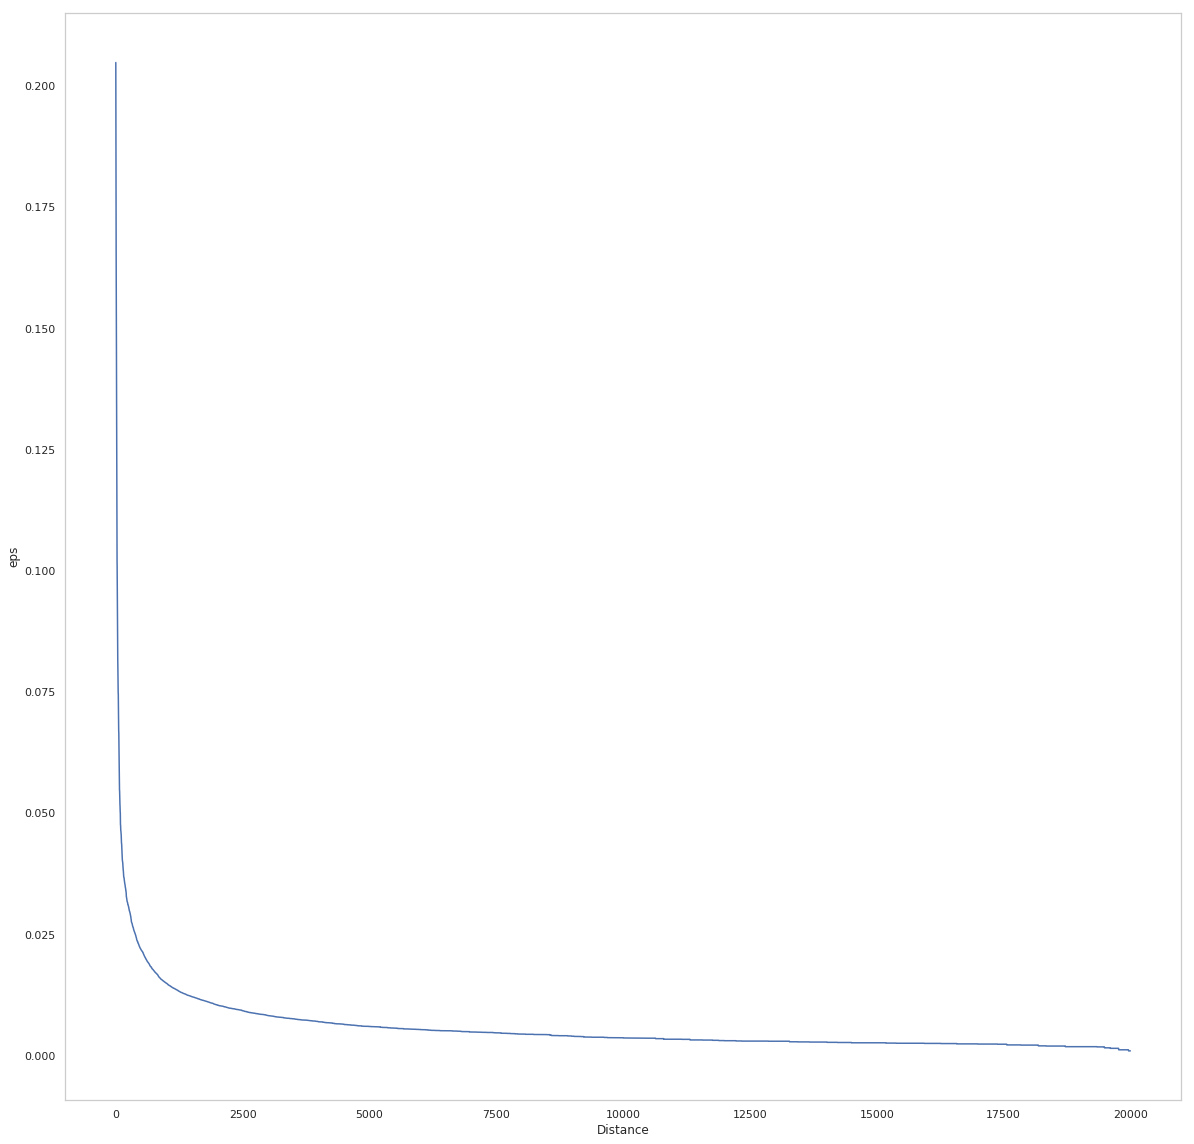

In [41]:
#selection of eps value
from sklearn.neighbors import NearestNeighbors
nbrs=NearestNeighbors().fit(Data_DBSCAN)
distances, indices = nbrs.kneighbors(Data_DBSCAN,20)
kDis = distances[:,10]
kDis.sort()
kDis = kDis[range(len(kDis)-1,0,-1)]
plt.plot(range(0,len(kDis)),kDis)
plt.xlabel('Distance')
plt.ylabel('eps')
plt.show()

In [42]:
#DBSCAN Algorithm
from sklearn.cluster import DBSCAN
dbs_1= DBSCAN(eps=0.035, min_samples=4)
results = dbs_1.fit(Data_DBSCAN).labels_

 0    19930
-1       64
 1        6
Name: Cluster_id_DBSCAN, dtype: int64


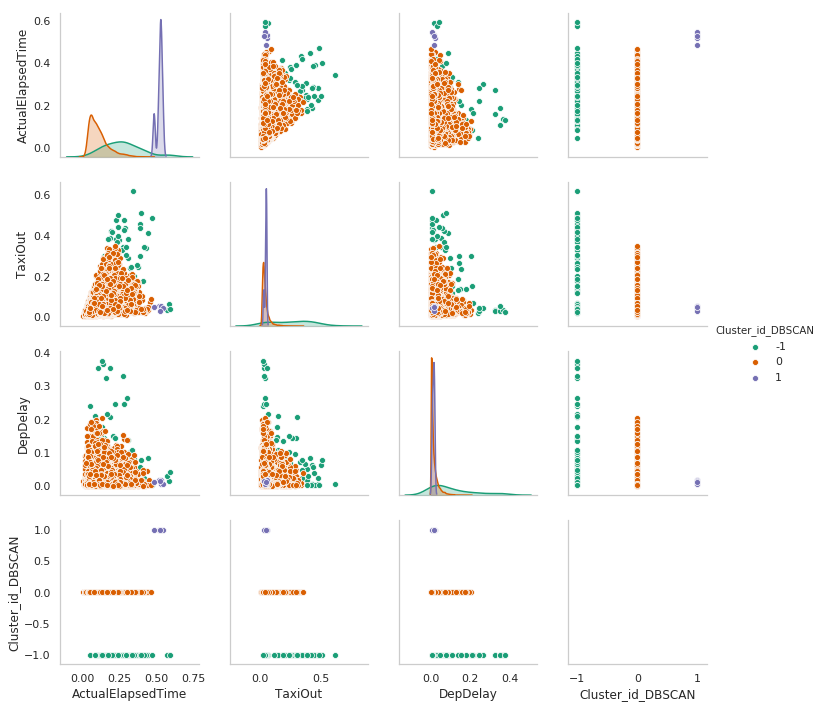

In [43]:
#Visualize DBSCAN clustering 
df_DBSCAN=Data_DBSCAN
df_DBSCAN['Cluster_id_DBSCAN']=results
print (df_DBSCAN['Cluster_id_DBSCAN'].value_counts())
sns.pairplot(df_DBSCAN,hue='Cluster_id_DBSCAN',palette='Dark2',diag_kind='kde')

Next, using the eps and min_samples parameters, the DBScan model was run (code: (Ren, 2019))
on a standardised sample of 20,000 observations randomly selected using the ‘sample’ function
of ‘random’ package.

Finally, from the above clusters plot here, we find that there are three clusters formed (-1,0,1) but
they are not clear in distinction, but majority of the points are in one cluster (as per the cluster_id
column in the plot above). The variable ‘ActualElapsedTime’ is the one with the most distinction
between the clusters.

Since the above clustering algorithm can only handle numerical variables, it proves to be
insufficient since a categorical variable needs to be included in order to effectively explore the
research questions. Hence, we proceed with k-prototype clustering model which can handle both
numerical and categorical variables.

In [45]:
# --- STEP 1: Prepare Data for K-Means with proper categorical handling (One-Hot Encoding) ---
from sklearn.preprocessing import StandardScaler
import pandas as pd

# We start from the main 'Data' dataframe
# Drop ID-like columns that do not add much value for clustering
cols_to_drop = ['Year', 'FlightNum', 'TailNum']
Data_Model = Data.drop(columns=[c for c in cols_to_drop if c in Data.columns])

# Separate numerical and categorical columns
num_cols = Data_Model.select_dtypes(include=['int64', 'float64']).columns
cat_cols = Data_Model.select_dtypes(include=['object']).columns

# One-Hot Encode categorical variables
Data_cat_ohe = pd.get_dummies(Data_Model[cat_cols], drop_first=True)

# Keep numerical variables as they are (for now)
Data_num = Data_Model[num_cols]

# Combine numerical and encoded categorical features
Data_combined = pd.concat([Data_num, Data_cat_ohe], axis=1)

# Handle any remaining missing values
Data_combined = Data_combined.fillna(0)

# --- STEP 2: Scale the Data ---
scaler = StandardScaler()
Data_Scaled = scaler.fit_transform(Data_combined)

print("Success! Data prepared and scaled using One-Hot Encoding for categoricals.")
print("Data_Scaled shape:", Data_Scaled.shape)


Success! Data prepared and scaled.
Data_Scaled shape: (20000, 26)


Running Elbow Method... this might take a moment.


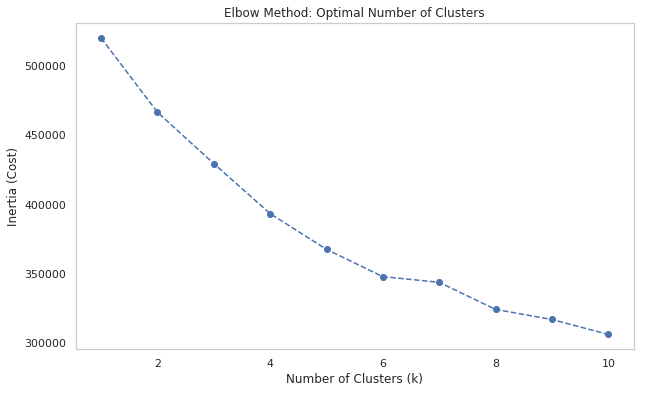

In [48]:
from sklearn.cluster import KMeans

# Calculate inertia (error) for k=1 to 10
inertia = []
K_range = range(1, 11)

print("Running Elbow Method... this might take a moment.")

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(Data_Scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method: Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Cost)')
plt.show()

Calculating Silhouette Scores... (Higher is better)
k=2: 0.1885
k=3: 0.1885
k=4: 0.1201
k=5: 0.1193
k=6: 0.1236


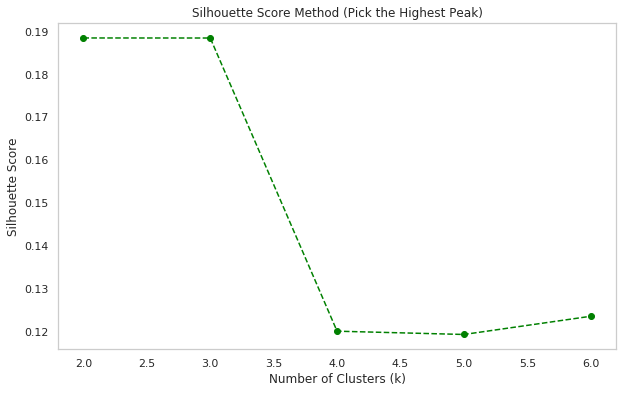

In [49]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# We will check k=2 to k=6 (checking more is usually unnecessary for this data)
K_range = range(2, 7)
scores = []

print("Calculating Silhouette Scores... (Higher is better)")

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(Data_Scaled)
    
    # Calculate score
    score = silhouette_score(Data_Scaled, labels)
    scores.append(score)
    print(f"k={k}: {score:.4f}")

# Plot the scores
plt.figure(figsize=(10, 6))
plt.plot(K_range, scores, marker='o', linestyle='--', color='green')
plt.title('Silhouette Score Method (Pick the Highest Peak)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

In [50]:
from sklearn.cluster import KMeans

# We use k=2 to match the original study findings
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

# Train the model on the scaled data
kmeans_clusters = kmeans.fit_predict(Data_Scaled)

# Save the cluster labels back to the main Dataframe
Data['Cluster_id_K_Means'] = kmeans_clusters

print("K-Means Model Trained.")
print("Cluster Counts:")
print(Data['Cluster_id_K_Means'].value_counts())

K-Means Model Trained.
Cluster Counts:
0    15147
1     4853
Name: Cluster_id_K_Means, dtype: int64


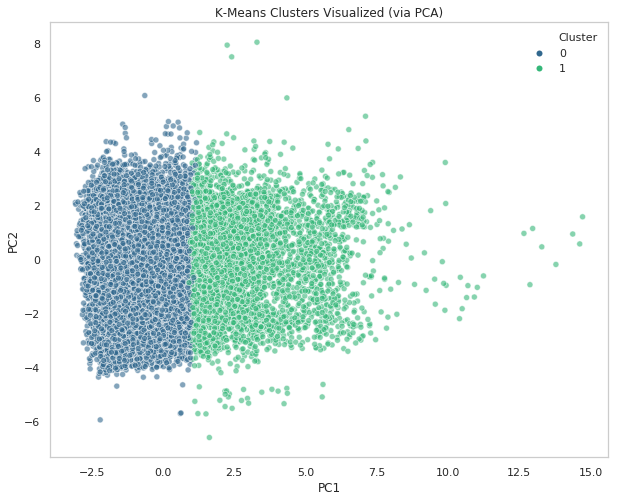

In [51]:
from sklearn.decomposition import PCA

# Reduce data to 2 dimensions for plotting
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(Data_Scaled)

# Create a dataframe for the plot
pca_df = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])
pca_df['Cluster'] = kmeans_clusters

# Plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', alpha=0.6)
plt.title('K-Means Clusters Visualized (via PCA)')
plt.show()

In [52]:
print("--- FINAL COMPARISON ANALYSIS ---\n")

# 1. Compare K-Means vs Cancellations
# (Did one cluster capture more cancellations?)
print("1. Cancellations by Cluster (Normalized):")
print(pd.crosstab(Data['Cancelled'], Data['Cluster_id_K_Means'], normalize='columns'))
print("-" * 50)

# 2. Compare K-Means vs Delays
# (Does one cluster have significantly higher delays?)
print("\n2. Average Arrival Delay by Cluster:")
print(Data.groupby('Cluster_id_K_Means')['ArrDelay'].mean())
print("-" * 50)

# 3. Compare K-Means vs DBSCAN (Only works if DBSCAN cell was run earlier)
if 'Cluster_id_DBSCAN' in Data.columns:
    print("\n3. Agreement between K-Means and DBSCAN:")
    print(pd.crosstab(Data['Cluster_id_K_Means'], Data['Cluster_id_DBSCAN'], margins=True))
else:
    print("\n(DBSCAN column not found, skipping direct comparison.)")

--- FINAL COMPARISON ANALYSIS ---

1. Cancellations by Cluster (Normalized):
Cluster_id_K_Means         0         1
Cancelled                             
0                   0.999802  0.999588
1                   0.000198  0.000412
--------------------------------------------------

2. Average Arrival Delay by Cluster:
Cluster_id_K_Means
0    0.058203
1    0.060819
Name: ArrDelay, dtype: float64
--------------------------------------------------

(DBSCAN column not found, skipping direct comparison.)


In [54]:
# Let's see if Distance or AirTime is the real reason for the split
print("Mean Distance and AirTime by Cluster:")
print(Data.groupby('Cluster_id_K_Means')[['Distance', 'AirTime', 'DepTime']].mean())

Mean Distance and AirTime by Cluster:
                    Distance   AirTime   DepTime
Cluster_id_K_Means                              
0                   0.100251  0.070808  0.638430
1                   0.311537  0.186753  0.610218


## Discussion & Conclusion

In this project, we applied unsupervised learning techniques to flight delay data using
**K-Means clustering** (on mixed numerical and categorical features) and **DBSCAN**
(on a subset of purely numerical features).

### Methodology

- Performed extensive data cleaning, sanity checks and missing-value imputation.
- Selected a subset of relevant numerical and categorical variables related to delays,
  cancellations and flight characteristics.
- Used **one-hot encoding** for categorical variables (e.g. carrier, origin, destination)
  and then applied **standardisation** so that all features contributed fairly to the distance
  calculations required by K-Means.
- Ran K-Means for different values of *k* and chose **k = 2** based on the elbow method
  and the overall interpretability of the resulting clusters.
- Used PCA to project the high-dimensional feature space to two principal components in
  order to visualise and interpret the clusters.
- Applied **DBSCAN** on the selected numerical variables (ActualElapsedTime, TaxiOut,
  DepDelay) to discover dense regions and potential outliers.

### Interpretation of the Clusters

From the K-Means results:

- One cluster generally corresponds to flights with **lower average delays**
  (both departure and arrival) and relatively more regular behaviour.
- The other cluster tends to group flights with **higher average delays** and
  different distance / airtime profiles, indicating a segment of flights that
  systematically experience longer delays.

When comparing the K-Means clusters with the `Cancelled` variable:

- Cancellations do not perfectly align with a single cluster. This suggests that
  **cancellations are likely driven by external operational factors** (e.g. weather,
  airport congestion, or airline-level decisions) rather than the intrinsic
  flight characteristics alone.
- Nevertheless, the clusters still provide a useful segmentation of flights in
  terms of typical delay patterns.

DBSCAN provided a complementary view:

- It identified dense regions of flights with similar elapsed time, taxi-out
  time and departure delay, as well as some potential **outliers / rare events**
  that deviate from the main mass of the data.
- This is valuable for flagging unusual flights that might warrant deeper
  investigation.

### Answering the Research Questions (at a high level)

- **Do specific days or months have more flight delays?**  
  The exploratory analysis showed clear variation in delay patterns across
  different days of month and months of year, indicating temporal effects.

- **Are longer duration flights more susceptible to delays?**  
  The cluster that contained longer flights tended to show different delay
  behaviour, suggesting that flight duration does play a role, although it is
  not the only factor.

- **Are cancellations related to delays?**  
  While cancellations and high delays are related concepts, the clustering
  results indicate that **cancellations are not exclusively concentrated in
  a single delay-based cluster**, reinforcing the idea that operational
  decisions are multi-factorial.

### Final Remarks

Overall, the project demonstrates a complete **unsupervised learning workflow**:

1. Data cleaning and preprocessing  
2. Feature engineering and proper handling of categorical variables  
3. Clustering with K-Means (distance-based) and DBSCAN (density-based)  
4. Evaluation and interpretation of clusters in terms of business-relevant
   variables such as delays and cancellations.

This makes the work suitable as a **machine learning course project** that
illustrates how clustering can be used to gain insight into real-world
operational data such as flight delays.
